# Random Forest AML transaction detector

**Objective:** train and evaluate one reasonably small Random Forest for transaction-level money-laundering detection using `dataset.csv` from `data_cleaning.ipynb`.

The experiment excludes label proxies and AMLNet-generated risk outputs. It uses a chronological split and only transaction information or account history available by the time each transaction occurs.

In [1]:
from pathlib import Path
import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, average_precision_score

RANDOM_SEED = 2137
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

DATA_PATH = Path("dataset.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Run data_cleaning.ipynb first so that dataset.csv exists.")

## Plan

1. Load only permissible transaction fields.
2. Add a compact set of amount, time, and causal history features.
3. Split chronologically: earliest 60% train, next 20% validation, latest 20% test.
4. Train a class-weighted Random Forest.
5. Choose the alert threshold on validation F1 and apply it unchanged to the test period.

Average precision is the main ranking metric because only about 0.16% of transactions are positive.

In [2]:
usecols = [
    "type", "category", "orig", "dest", "old_balance",
    "new_balance", "is_fraud", "payment_method", "location.city",
    "device_info.type", "device_info.os", "datetime",
]
dtypes = {
    "type": "category", "category": "category",
    "orig": "category", "dest": "category",
    "old_balance": "float32", "new_balance": "float32",
    "is_fraud": "int8", "payment_method": "category",
    "location.city": "category",
    "device_info.type": "category", "device_info.os": "category",
}

df = pd.read_csv(
    DATA_PATH, usecols=usecols, dtype=dtypes, parse_dates=["datetime"]
)
df = df.sort_values("datetime", kind="stable").reset_index(drop=True)

display(pd.DataFrame({
    "transactions": [len(df)],
    "laundering_transactions": [int(df["is_fraud"].sum())],
    "positive_rate": [df["is_fraud"].mean()],
    "first_timestamp": [df["datetime"].min()],
    "last_timestamp": [df["datetime"].max()],
}))

,transactions,laundering_transactions,positive_rate,first_timestamp,last_timestamp
0,1090172,1745,0.0016,2025-02-04 11:15:40,2025-08-18 19:15:03


## Feature construction

The model receives amount and balance features, cyclic time-of-day, broad categorical attributes, and a few prior-history features. `orig` and `dest` are not direct inputs; they are used only to calculate histories.

The data is sorted before `cumcount`, `shift`, and cumulative sums are calculated, so the current transaction and future transactions do not contribute to its history.

In [3]:
# feature vomit

df["amount"] = (df["old_balance"] - df["new_balance"]).clip(lower=0).astype("float32")
df["log_amount"] = np.log1p(df["amount"]).astype("float32")
df["log_old_balance"] = np.log1p(df["old_balance"].clip(lower=0)).astype("float32")
df["balance_fraction"] = (
    df["amount"] / df["old_balance"].clip(lower=1)
).clip(0, 1).astype("float32")
hour = df["datetime"].dt.hour + df["datetime"].dt.minute / 60
df["hour_sin"] = np.sin(2 * np.pi * hour / 24).astype("float32")
df["hour_cos"] = np.cos(2 * np.pi * hour / 24).astype("float32")
df["is_weekend"] = (df["datetime"].dt.dayofweek >= 5).astype("float32")
df["destination_is_merchant"] = (
    df["dest"].astype(str).str.startswith("M")
).astype("float32")
df["near_threshold"] = df["amount"].between(
    8_500, 10_000, inclusive="left"
).astype("float32")

orig_prior_count = df.groupby("orig", observed=True).cumcount().astype("float32")
dest_prior_count = df.groupby("dest", observed=True).cumcount().astype("float32")
pair_prior_count = df.groupby(["orig", "dest"], observed=True).cumcount().astype("float32")
df["log_orig_prior_count"] = np.log1p(orig_prior_count).astype("float32")
df["log_dest_prior_count"] = np.log1p(dest_prior_count).astype("float32")
df["log_pair_prior_count"] = np.log1p(pair_prior_count).astype("float32")

previous_time = df.groupby("orig", observed=True)["datetime"].shift()
hours_since_previous = (
    (df["datetime"] - previous_time).dt.total_seconds() / 3_600
).clip(lower=0)
df["log_hours_since_orig_tx"] = np.log1p(hours_since_previous).astype("float32")

prior_amount_sum = df.groupby("orig", observed=True)["amount"].cumsum() - df["amount"]
prior_amount_mean = prior_amount_sum / orig_prior_count.replace(0, np.nan)
amount_ratio = (df["amount"] / prior_amount_mean.clip(lower=1)).clip(upper=100)
df["log_amount_vs_orig_mean"] = np.log1p(amount_ratio).astype("float32")

In [4]:
n_rows = len(df)
train_end = int(0.60 * n_rows)
validation_end = int(0.80 * n_rows)
split_slices = {
    "train": slice(0, train_end),
    "validation": slice(train_end, validation_end),
    "test": slice(validation_end, None),
}
split_summary = []
for name, rows in split_slices.items():
    part = df.iloc[rows]
    split_summary.append({
        "split": name, "rows": len(part),
        "positives": int(part["is_fraud"].sum()),
        "positive_rate": part["is_fraud"].mean(),
        "start": part["datetime"].min(), "end": part["datetime"].max(),
    })
display(pd.DataFrame(split_summary).set_index("split"))

,rows,positives,positive_rate,start,end
split,,,,,
train,654103,1071,0.0016,2025-02-04 11:15:40,2025-05-23 04:00:16
validation,218034,372,0.0017,2025-05-23 04:00:23,2025-06-27 22:40:49
test,218035,302,0.0014,2025-06-27 22:41:05,2025-08-18 19:15:03


In [5]:
numeric_features = [
    "log_amount", "log_old_balance", "balance_fraction",
    "hour_sin", "hour_cos", "is_weekend",
    "destination_is_merchant", "near_threshold",
    "log_orig_prior_count", "log_dest_prior_count",
    "log_pair_prior_count", "log_hours_since_orig_tx",
    "log_amount_vs_orig_mean",
]
categorical_features = [
    "type", "category", "payment_method", "location.city",
    "device_info.type", "device_info.os",
]
train_frame = df.iloc[:train_end]
numeric_medians = train_frame[numeric_features].median()
category_levels = {
    column: sorted(train_frame[column].dropna().unique().tolist())
    for column in categorical_features
}
feature_names = numeric_features.copy()
for column in categorical_features:
    feature_names.extend(
        f"{column}={level}" for level in category_levels[column][1:]
    )

def make_matrix(frame):
    blocks = [frame[numeric_features].fillna(numeric_medians).to_numpy(np.float32)]
    for column in categorical_features:
        blocks.append(np.column_stack([
            (frame[column] == level).to_numpy(np.float32)
            for level in category_levels[column][1:]
        ]))
    return np.column_stack(blocks).astype(np.float32, copy=False)

X_train = make_matrix(df.iloc[:train_end])
X_validation = make_matrix(df.iloc[train_end:validation_end])
X_test = make_matrix(df.iloc[validation_end:])
y_train = df["is_fraud"].iloc[:train_end].to_numpy(np.int8)
y_validation = df["is_fraud"].iloc[train_end:validation_end].to_numpy(np.int8)
y_test = df["is_fraud"].iloc[validation_end:].to_numpy(np.int8)

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(X_train), len(X_validation), len(X_test)],
    "features": [X_train.shape[1]] * 3,
}).set_index("split"))
del train_frame, df
gc.collect()

,rows,features
split,,
train,654103,42
validation,218034,42
test,218035,42


54

## Train the Random Forest

Balanced class weights make the rare laundering rows influential without oversampling. Tree depth and minimum leaf size are constrained to keep training fast and reduce memorization.

In [6]:
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=16,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)
start = time.perf_counter()
model.fit(X_train, y_train)
fit_seconds = time.perf_counter() - start
print(f"fit time: {fit_seconds:.2f} seconds")

fit time: 14.02 seconds


validation-selected alert threshold: 0.5416


,average_precision,precision,recall,f1
split,,,,
validation,0.9211,0.9434,0.8065,0.8696
test,0.9257,0.9478,0.8411,0.8912


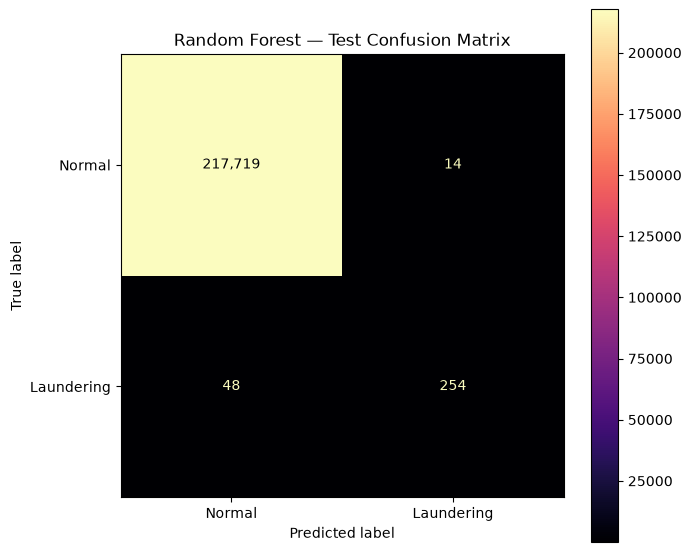

In [7]:
def best_f1_threshold(y_true, scores):
    order = np.argsort(-scores, kind="stable")
    ranked_y = y_true[order]
    true_positives = np.cumsum(ranked_y)
    false_positives = np.cumsum(1 - ranked_y)
    false_negatives = ranked_y.sum() - true_positives
    f1 = 2 * true_positives / (
        2 * true_positives + false_positives + false_negatives + 1e-12
    )
    best_index = int(np.argmax(f1))
    return float(scores[order[best_index]])

def classification_metrics(y_true, scores, threshold):
    predicted = scores >= threshold
    tp = int(((predicted == 1) & (y_true == 1)).sum())
    fp = int(((predicted == 1) & (y_true == 0)).sum())
    fn = int(((predicted == 0) & (y_true == 1)).sum())
    tn = int(((predicted == 0) & (y_true == 0)).sum())
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {
        "average_precision": average_precision_score(y_true, scores),
        "precision": precision, "recall": recall, "f1": f1,
        "alerts": tp + fp, "true_positives": tp,
        "false_positives": fp, "false_negatives": fn,
        "true_negatives": tn,
    }

validation_scores = model.predict_proba(X_validation)[:, 1]
test_scores = model.predict_proba(X_test)[:, 1]
alert_threshold = best_f1_threshold(y_validation, validation_scores)
results = pd.DataFrame.from_dict({
    "validation": classification_metrics(
        y_validation, validation_scores, alert_threshold
    ),
    "test": classification_metrics(y_test, test_scores, alert_threshold),
}, orient="index")
results.index.name = "split"
print(f"validation-selected alert threshold: {alert_threshold:.4f}")
display(results[["average_precision", "precision", "recall", "f1"]])

fig, axis = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_scores >= alert_threshold,
    display_labels=["Normal", "Laundering"],
    cmap="magma",
    colorbar=True,
    values_format=",d",
    ax=axis,
)
axis.set_title("Random Forest — Test Confusion Matrix")
fig.tight_layout()
plt.show()

In [8]:
feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .head(12)
    .reset_index(drop=True)
)
display(feature_importance)

,feature,importance
0,balance_fraction,0.2107
1,log_amount,0.1650
2,type=TRANSFER,0.1597
3,category=Other,0.1119
4,log_amount_vs_orig_mean,0.1014
5,destination_is_merchant,0.0547
6,category=Housing,0.0483
7,type=DEBIT,0.0379
8,log_dest_prior_count,0.0167
9,log_pair_prior_count,0.0108
